# Clasificación de sentimiento: SLM promptado vs. baseline TF-IDF

Este notebook compara de forma controlada dos enfoques para clasificar
reseñas de películas (IMDB) como positivas o negativas:

1. **Baseline tradicional**: TF-IDF + Regresión Logística, entrenado sobre
   el conjunto de entrenamiento con selección de hiperparámetros mediante
   validación cruzada.
2. **SLM promptado**: `Qwen2.5-0.5B-Instruct` usado en modo zero-shot y
   few-shot, con diferentes plantillas de prompt y políticas de longitud
   de entrada.

## Pregunta de investigación

*¿Cuándo tiene sentido usar un SLM promptado en lugar de un clasificador
tradicional entrenado sobre el mismo dominio?*

## Principios del diseño experimental

- Un único split estratificado **70 / 15 / 15** (train / val / test).
- Los baselines se entrenan **solo** sobre train.
- La selección de prompts y de configuración del SLM se hace **solo**
  sobre validación.
- El resultado final se calcula **una única vez** sobre test.
- Todas las comparaciones finales usan el **mismo** subsample de test.
- Se reportan intervalos de confianza bootstrap al 95% para las métricas
  principales.

Este notebook reemplaza una versión anterior (`llm_diplo.ipynb`,
ahora en `notebooks/archive/`) que tenía fuga de datos entre selección de
prompts y evaluación final, y donde el baseline y el SLM no se evaluaban
sobre los mismos ejemplos.


## 1. Preparación del entorno


In [1]:
# Dependencias (descomentar la primera vez en Colab).
# !pip -q install 'transformers>=4.44' accelerate tqdm scikit-learn seaborn


In [28]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import platform

# Agregamos la raíz del repo al path para importar los módulos de src/.
# En Colab: clonar el repo y ajustar REPO_ROOT a /content/llm-text-classification-comparison.
REPO_ROOT = Path.cwd().parent  # notebooks/ -> raíz del repo
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src import data as data_mod
from src import classify as classify_mod
from src import evaluate as eval_mod

SEED = 42
np.random.seed(SEED)

print('Modulos src/ importados correctamente.')


Modulos src/ importados correctamente.


## 2. Carga de datos y particionado

El CSV proviene de un dump plano (Kaggle-style): únicamente contiene las
columnas `review` y `sentiment`, sin indicador de split oficial. Por eso
generamos un split 70 / 15 / 15 propio, estratificado por sentimiento,
con `random_state=42`.


In [3]:
# Descarga del dataset (la primera vez). En Colab se descarga directamente.
DATA_PATH = REPO_ROOT / 'data' / 'raw' / 'imdb_dataset.csv'
DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    import urllib.request
    file_id = '1hK3hjvuoVUUV_kW8FyVE33iGig9wN0K3'
    url = f'https://drive.usercontent.google.com/download?id={file_id}&export=download'
    print(f'Descargando dataset a {DATA_PATH} ...')
    urllib.request.urlretrieve(url, DATA_PATH)

df = data_mod.load_imdb(str(DATA_PATH))
print(f'Resenas cargadas tras deduplicacion: {len(df):,}')
print(df['sentiment'].value_counts())


Descargando dataset a /Users/nicochade/Documents/projects/portfolio/llm-text-classification-comparison/data/raw/imdb_dataset.csv ...
Resenas cargadas tras deduplicacion: 49,582
sentiment
positive    24884
negative    24698
Name: count, dtype: int64


In [4]:
# Split estratificado 70/15/15 con seed fija.
train_df, val_df, test_df = data_mod.split_dataset(df, seed=SEED)
print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
print('\nBalance de clases por split:')
print(pd.DataFrame({
    'train': train_df['sentiment'].value_counts(normalize=True),
    'val':   val_df['sentiment'].value_counts(normalize=True),
    'test':  test_df['sentiment'].value_counts(normalize=True),
}).round(3))


Train: 34,707 | Val: 7,437 | Test: 7,438

Balance de clases por split:
           train    val   test
sentiment                     
positive   0.502  0.502  0.502
negative   0.498  0.498  0.498


### Verificación de ausencia de fuga entre splits

Verificamos explícitamente que los índices de los tres splits no se
solapen. Si esta celda no falla, no hay solapamiento por construcción.


In [5]:
train_idx = set(train_df.index)
val_idx = set(val_df.index)
test_idx = set(test_df.index)

print(f'|train ∩ val|  = {len(train_idx & val_idx)}')
print(f'|train ∩ test| = {len(train_idx & test_idx)}')
print(f'|val ∩ test|   = {len(val_idx & test_idx)}')

assert len(train_idx & val_idx) == 0
assert len(train_idx & test_idx) == 0
assert len(val_idx & test_idx) == 0
print('\nNo hay solapamiento entre splits.')


|train ∩ val|  = 0
|train ∩ test| = 0
|val ∩ test|   = 0

No hay solapamiento entre splits.


### Subsamples estratificados para inferencia del SLM

A ~6 reseñas/seg en una T4, evaluar los 7.4K ejemplos de val o test con
el SLM tomaría ~20 minutos por configuración. Para poder comparar varios
prompts sin comprometer la rigurosidad, trabajamos sobre subsamples de
1000 reseñas (500 por clase) extraídas *dentro* de cada split.

**Todas las comparaciones finales se hacen sobre el mismo subsample de
test.** El baseline TF-IDF se evalúa tanto sobre el test completo
(como sanidad) como sobre el subsample (para la comparación cabeza a
cabeza con el SLM).


In [6]:
val_sample = data_mod.subsample(val_df, n_per_class=500, seed=SEED)
test_sample = data_mod.subsample(test_df, n_per_class=500, seed=SEED)
print(f'val_sample:  {len(val_sample)} (balance: {dict(val_sample.sentiment.value_counts())})')
print(f'test_sample: {len(test_sample)} (balance: {dict(test_sample.sentiment.value_counts())})')


val_sample:  1000 (balance: {'positive': np.int64(500), 'negative': np.int64(500)})
test_sample: 1000 (balance: {'negative': np.int64(500), 'positive': np.int64(500)})


### Selección determinista de ejemplos few-shot

Para el prompt few-shot (`fs_train`) necesitamos un ejemplo positivo y
uno negativo extraídos del conjunto de entrenamiento. Regla:

- Agrupar train por sentimiento.
- Dentro de cada clase, ordenar por índice original (orden del DataFrame).
- Tomar la primera reseña.
- Truncarla a sus primeras 50 palabras para mantener el prompt corto.

Este procedimiento es 100% reproducible desde la semilla y el split.
Si los ejemplos resultaran muy malos (e.g., casi vacíos, o
texto sin sentimiento claro), la regla alternativa definida es:
*tomar la reseña de longitud mediana de cada clase en train*.


In [7]:
fs_examples = data_mod.select_few_shot_examples(train_df, n_per_class=1, max_words=50)
print('Ejemplos few-shot seleccionados (indices originales de train):')
for idx, row in fs_examples.iterrows():
    print(f'  [{idx}] {row.sentiment:>8s} -> {row.review}')


Ejemplos few-shot seleccionados (indices originales de train):
  [3] negative -> Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time. This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie. OK, first of all when you're going
  [0] positive -> One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me. The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the


## 3. Baseline tradicional: TF-IDF + Regresión Logística

Pipeline estándar con selección de hiperparámetros vía `GridSearchCV` de
3 folds **sobre el conjunto de train**. No se toca val ni test durante
la selección.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

pipe = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf', LogisticRegression(max_iter=1000, penalty='l2')),
])

param_grid = {
    'tfidf__max_features': [5000, 10000, 20000],
    'clf__C': [0.1, 1.0, 10.0],
}

gs = GridSearchCV(pipe, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
t0 = time.time()
gs.fit(train_df['review'], train_df['sentiment'])
fit_time = time.time() - t0

print(f'Tiempo de ajuste (GridSearchCV 3-fold): {fit_time:.1f} s')
print(f'Mejores parametros: {gs.best_params_}')
print(f'Mejor f1_macro (CV): {gs.best_score_:.4f}')
best_pipe = gs.best_estimator_


/Users/nicochade/miniforge3/envs/llm-text-classification/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nicochade/miniforge3/envs/llm-text-classification/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nicochade/miniforge3/envs/llm-text-classification/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:

Tiempo de ajuste (GridSearchCV 3-fold): 44.1 s
Mejores parametros: {'clf__C': 10.0, 'tfidf__max_features': 20000}
Mejor f1_macro (CV): 0.9006


### Desempeño del baseline sobre el test completo (7.4K reseñas)

Reportamos este número como sanidad del baseline en un volumen grande;
la comparación con el SLM se hace después, sobre el subsample de test.


In [9]:
t0 = time.time()
pred_tfidf_full = best_pipe.predict(test_df['review'])
tfidf_predict_time_full = time.time() - t0

print(f'Tiempo de inferencia TF-IDF sobre test completo ({len(test_df)}): {tfidf_predict_time_full:.2f} s')
print(classification_report(test_df['sentiment'], pred_tfidf_full, digits=3))


Tiempo de inferencia TF-IDF sobre test completo (7438): 0.91 s
              precision    recall  f1-score   support

    negative      0.916     0.896     0.906      3705
    positive      0.899     0.918     0.908      3733

    accuracy                          0.907      7438
   macro avg      0.907     0.907     0.907      7438
weighted avg      0.907     0.907     0.907      7438



### Desempeño del baseline sobre el subsample de test (1000 reseñas)

Este es el número que va a la comparación final.


In [10]:
t0 = time.time()
pred_tfidf_sample = best_pipe.predict(test_sample['review'])
tfidf_predict_time_sample = time.time() - t0

print(f'Tiempo de inferencia TF-IDF sobre subsample ({len(test_sample)}): {tfidf_predict_time_sample:.3f} s')
print(classification_report(test_sample['sentiment'], pred_tfidf_sample, digits=3))


Tiempo de inferencia TF-IDF sobre subsample (1000): 0.130 s
              precision    recall  f1-score   support

    negative      0.913     0.904     0.909       500
    positive      0.905     0.914     0.909       500

    accuracy                          0.909      1000
   macro avg      0.909     0.909     0.909      1000
weighted avg      0.909     0.909     0.909      1000



## 4. SLM promptado: Qwen2.5-0.5B-Instruct

Cargamos `Qwen/Qwen2.5-0.5B-Instruct` (ventana de contexto 32K tokens),
definimos los prompts candidatos y medimos la tasa de truncado bajo
dos topes explícitos de longitud de entrada: **256** y **1024** tokens.

Nota: en la versión anterior del notebook se probó `Qwen3-0.6B` pero el
modelo emite tokens internos de razonamiento (`<think>...</think>`) que
rompen el parsing de etiqueta. Se descartó por esa razón.


In [11]:
tok, model = classify_mod.load_model('Qwen/Qwen2.5-0.5B-Instruct')
print('Modelo cargado.')


`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 290/290 [00:00<00:00, 337.05it/s]


Modelo cargado.


### Prompts candidatos

Cuatro plantillas: tres zero-shot (inglés estricto, español estricto,
calibrado) y una few-shot construida dinámicamente con los ejemplos de
train seleccionados más arriba.


In [12]:
fs_system, fs_user = classify_mod.build_fs_prompt(fs_examples)

PROMPTS = {
    'zs_strict_en':  classify_mod.PROMPTS['zs_strict_en'],
    'zs_strict_es':  classify_mod.PROMPTS['zs_strict_es'],
    'zs_calibrated': classify_mod.PROMPTS['zs_calibrated'],
    'fs_train':      (fs_system, fs_user),
}

for name, (sys_t, _) in PROMPTS.items():
    print(f'--- {name} ---')
    print(sys_t)
    print()


--- zs_strict_en ---
You are a sentiment classifier. Reply with EXACTLY one word: positive or negative. No punctuation, no explanations.

--- zs_strict_es ---
Eres un clasificador de sentimiento. Responde con UNA sola palabra EXACTA: positive o negative. Sin puntuacion ni explicacion.

--- zs_calibrated ---
You are a strict classifier. Prior over classes is equal. If uncertain, still choose exactly one from: positive, negative. Any other output is invalid.

--- fs_train ---
You are a sentiment classifier. Reply with EXACTLY one word: positive or negative. No punctuation, no explanations.



### Política de longitud de entrada: medición

Antes de correr el grid, medimos qué fracción de reseñas excede cada tope
de longitud en el val_sample. Esto permite contextualizar el efecto del
recorte de entrada.


In [27]:
rate_256  = classify_mod.count_truncation_rate(tok, val_sample['review'], 256)
rate_1024 = classify_mod.count_truncation_rate(tok, val_sample['review'], 1024)
print(f'Fraccion de reseñas truncadas a 256 tokens:  {rate_256:.1%}')
print(f'Fraccion de reseñas truncadas a 1024 tokens: {rate_1024:.1%}')


Fraccion de reseñas truncadas a 256 tokens:  38.5%
Fraccion de reseñas truncadas a 1024 tokens: 2.0%


### Chequeo rápido del SLM

Clasificamos 5 reseñas del val_sample para confirmar que el modelo
emite etiquetas parseables antes de lanzar el grid completo.


In [14]:
sanity = val_sample.head(5)
sys_t, user_t = PROMPTS['zs_strict_en']
sanity_preds = classify_mod.classify_batch(
    sanity['review'], tok, model, sys_t, user_t,
    max_input_tokens=1024, desc='sanity',
)
print(pd.DataFrame({'real': sanity['sentiment'].values, 'pred': sanity_preds}))


sanity: 100%|██████████| 5/5 [00:04<00:00,  1.21it/s]

       real      pred
0  positive  positive
1  positive  positive
2  negative  negative
3  positive  positive
4  positive  positive


### Grid de selección sobre validación

Evaluamos 6 configuraciones sobre el `val_sample` (1000 reseñas):

| ID | prompt | tope de entrada |
|----|--------|-----------------|
| P1 | zs_strict_en  | 1024 |
| P2 | zs_strict_es  | 1024 |
| P3 | zs_calibrated | 1024 |
| P4 | fs_train      | 1024 |
| P5 | zs_strict_en  |  256 |
| P6 | zs_strict_es  |  256 |

Todas usan decodificación greedy (`do_sample=False`) con `max_new_tokens=1`.
En el notebook anterior se probaron tres modos de decodificación y todos
daban exactamente el mismo resultado con 1 token de salida, por lo que esta vez
no variamos ese eje.


In [15]:
val_configs = [
    ('zs_strict_en',  1024),
    ('zs_strict_es',  1024),
    ('zs_calibrated', 1024),
    ('fs_train',      1024),
    ('zs_strict_en',   256),
    ('zs_strict_es',   256),
]

val_rows = []
val_preds_by_cfg = {}
val_time_by_cfg = {}
for prompt_name, cap in val_configs:
    sys_t, user_t = PROMPTS[prompt_name]
    t0 = time.time()
    preds = classify_mod.classify_batch(
        val_sample['review'], tok, model, sys_t, user_t,
        max_input_tokens=cap, desc=f'{prompt_name}/{cap}',
    )
    elapsed = time.time() - t0
    cfg_key = f'{prompt_name}_{cap}'
    val_preds_by_cfg[cfg_key] = preds
    val_time_by_cfg[cfg_key] = elapsed
    m = eval_mod.compute_metrics(val_sample['sentiment'], preds)
    val_rows.append({
        'prompt': prompt_name,
        'input_cap': cap,
        'accuracy': m['accuracy'],
        'f1_macro': m['f1_macro'],
        'unk_rate': m['unk_rate'],
        'elapsed_s': elapsed,
    })

val_grid = pd.DataFrame(val_rows).sort_values('f1_macro', ascending=False).reset_index(drop=True)
val_grid


zs_strict_es/256: 100%|██████████| 1000/1000 [01:08<00:00, 14.54it/s]


,prompt,input_cap,accuracy,f1_macro,unk_rate,elapsed_s
0,zs_strict_es,1024,0.940,0.939971,0.0,98.675023
1,zs_strict_en,1024,0.938,0.937996,0.0,103.088742
2,zs_strict_es,256,0.919,0.918993,0.0,68.776950
3,zs_strict_en,256,0.907,0.906922,0.0,129.494893
4,fs_train,1024,0.892,0.891118,0.0,132.482724
5,zs_calibrated,1024,0.797,0.789314,0.0,102.212562


### Interpretación del grid de validación

Observaciones a discutir a partir de la tabla:

- Cuál es el mejor prompt según `f1_macro` en validación.
- Cuánto cuesta en performance truncar a 256 tokens vs. 1024 tokens
  (efecto aislado del prompt).
- Si `zs_calibrated` se desempeña claramente peor, como habíamos visto
  en iteraciones previas, confirmando la sensibilidad al formato del
  prompt.
- Si el prompt en español supera al inglés sobre un dataset en inglés,
  reportarlo como **hallazgo empírico** sin sobregeneralizar: podría
  deberse a sesgos del mix de entrenamiento del modelo o a cómo tokeniza
  las instrucciones, y no es razón suficiente para recomendar prompts en
  español en general.

Guardamos el grid a `results/val_grid.csv` para reproducibilidad.


In [16]:
RESULTS_DIR = REPO_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)
val_grid.to_csv(RESULTS_DIR / 'val_grid.csv', index=False)

best_row = val_grid.iloc[0]
best_prompt = best_row['prompt']
best_cap = int(best_row['input_cap'])
print(f'Mejor configuracion en validacion: prompt={best_prompt}, cap={best_cap}')
print(f'  f1_macro={best_row.f1_macro:.4f}, accuracy={best_row.accuracy:.4f}, unk_rate={best_row.unk_rate:.3%}')


Mejor configuracion en validacion: prompt=zs_strict_es, cap=1024
  f1_macro=0.9400, accuracy=0.9400, unk_rate=0.000%


## 5. Evaluación final sobre test

Ejecutamos cada método **una sola vez** sobre el subsample de test:

1. **TF-IDF + LR** (ya entrenado, hiperparámetros fijados en train).
2. **SLM** con el mejor prompt + mejor tope de entrada de validación.
3. **SLM** con el mismo prompt pero tope agresivo de 256 tokens, para
   aislar el efecto del truncado sobre datos frescos.

Se reportan intervalos de confianza bootstrap al 95% sobre las 1000
muestras del subsample de test.


In [17]:
# SLM con la mejor configuración de validación.
sys_t, user_t = PROMPTS[best_prompt]

t0 = time.time()
pred_slm_best = classify_mod.classify_batch(
    test_sample['review'], tok, model, sys_t, user_t,
    max_input_tokens=best_cap, desc=f'slm_best_{best_prompt}_{best_cap}',
)
slm_best_time = time.time() - t0
print(f'Tiempo SLM ({best_prompt}, cap={best_cap}) sobre {len(test_sample)}: {slm_best_time:.1f} s')


slm_best_zs_strict_es_1024: 100%|██████████| 1000/1000 [01:35<00:00, 10.42it/s]

Tiempo SLM (zs_strict_es, cap=1024) sobre 1000: 96.0 s


In [18]:
# SLM con cap de 256 tokens (ablación de truncado sobre el mismo prompt).
t0 = time.time()
pred_slm_trunc = classify_mod.classify_batch(
    test_sample['review'], tok, model, sys_t, user_t,
    max_input_tokens=256, desc=f'slm_trunc_{best_prompt}_256',
)
slm_trunc_time = time.time() - t0
print(f'Tiempo SLM ({best_prompt}, cap=256) sobre {len(test_sample)}: {slm_trunc_time:.1f} s')


slm_trunc_zs_strict_es_256: 100%|██████████| 1000/1000 [01:11<00:00, 13.96it/s]

Tiempo SLM (zs_strict_es, cap=256) sobre 1000: 71.6 s


### Tabla comparativa con intervalos de confianza bootstrap


In [19]:
results_final = [
    {'name': 'TF-IDF + LR (tuned)',
     'y_true': test_sample['sentiment'].values,
     'y_pred': np.asarray(pred_tfidf_sample)},
    {'name': f'SLM {best_prompt} cap={best_cap}',
     'y_true': test_sample['sentiment'].values,
     'y_pred': np.asarray(pred_slm_best)},
    {'name': f'SLM {best_prompt} cap=256 (ablacion)',
     'y_true': test_sample['sentiment'].values,
     'y_pred': np.asarray(pred_slm_trunc)},
]

comp_df = eval_mod.comparison_table(results_final, n_boot=10_000, seed=SEED)
comp_df.to_csv(RESULTS_DIR / 'final_comparison.csv', index=False)
comp_df


,metodo,accuracy,accuracy_ci95,f1_macro,f1_macro_ci95,f1_positive,precision_macro,recall_macro,unk_rate
0,TF-IDF + LR (tuned),0.909,"[0.891, 0.926]",0.908998,"[0.891, 0.926]",0.909453,0.909041,0.909,0.0
1,SLM zs_strict_es cap=1024,0.921,"[0.904, 0.937]",0.920965,"[0.904, 0.937]",0.922625,0.921744,0.921,0.0
2,SLM zs_strict_es cap=256 (ablacion),0.909,"[0.891, 0.926]",0.908967,"[0.891, 0.926]",0.910697,0.909591,0.909,0.0


### Matrices de confusión


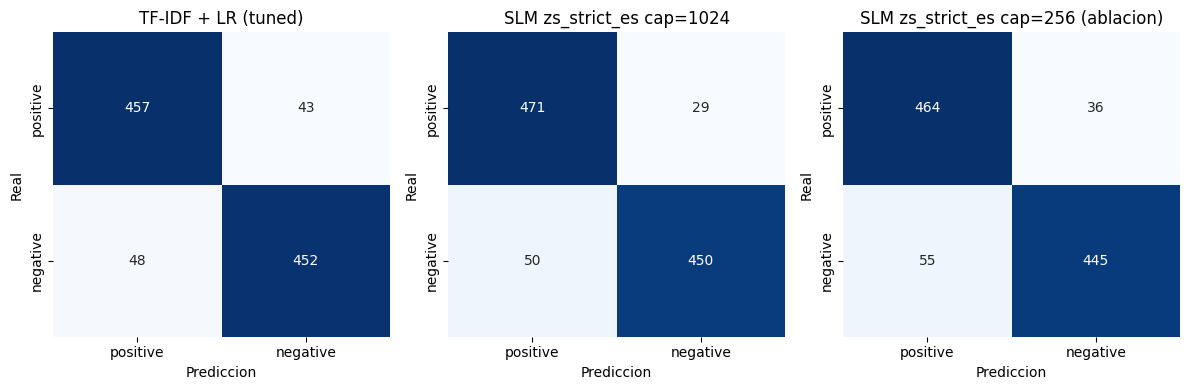

In [20]:
fig = eval_mod.plot_confusion_matrices(results_final)
plt.show()


### Reportes de clasificación completos


In [21]:
from sklearn.metrics import classification_report
for r in results_final:
    print(f'=== {r["name"]} ===')
    print(classification_report(r['y_true'], r['y_pred'], digits=3, zero_division=0))


=== TF-IDF + LR (tuned) ===
              precision    recall  f1-score   support

    negative      0.913     0.904     0.909       500
    positive      0.905     0.914     0.909       500

    accuracy                          0.909      1000
   macro avg      0.909     0.909     0.909      1000
weighted avg      0.909     0.909     0.909      1000

=== SLM zs_strict_es cap=1024 ===
              precision    recall  f1-score   support

    negative      0.939     0.900     0.919       500
    positive      0.904     0.942     0.923       500

    accuracy                          0.921      1000
   macro avg      0.922     0.921     0.921      1000
weighted avg      0.922     0.921     0.921      1000

=== SLM zs_strict_es cap=256 (ablacion) ===
              precision    recall  f1-score   support

    negative      0.925     0.890     0.907       500
    positive      0.894     0.928     0.911       500

    accuracy                          0.909      1000
   macro avg      0.91

## 6. Análisis de errores

Comparamos dónde falla cada método. Para cada una de las siguientes
categorías mostramos hasta 5 ejemplos aleatorios del test_sample:

- TF-IDF acierta, SLM falla.
- SLM acierta, TF-IDF falla.
- Ambos fallan.


In [22]:
ea_df = test_sample.copy()
ea_df['pred_tfidf'] = pred_tfidf_sample
ea_df['pred_slm'] = pred_slm_best

errors = eval_mod.error_analysis(
    ea_df,
    text_col='review',
    y_true_col='sentiment',
    pred_cols={'tfidf': 'pred_tfidf', 'slm': 'pred_slm'},
    n=5,
    seed=SEED,
)
# Truncamos el texto de la reseña para una tabla legible.
errors_display = errors.copy()
errors_display['review'] = errors_display['review'].str.slice(0, 220) + '...'
errors_display


,review,sentiment,pred_tfidf,pred_slm,error_type
38297,The tenuous connection between this film and t...,negative,negative,positive,tfidf_correct_slm_wrong
22293,Harrowing series about life in Oz--an experime...,positive,positive,negative,tfidf_correct_slm_wrong
35474,THE MELTING MAN...a tragic victim of the space...,positive,positive,negative,tfidf_correct_slm_wrong
7172,the reason why i gave this movie a 4 was for a...,negative,negative,positive,tfidf_correct_slm_wrong
48799,"Is Miike like Chabrol, alternating art with dr...",negative,negative,positive,tfidf_correct_slm_wrong
47490,I saw this movie in 1956 and again on Cable a ...,negative,positive,negative,slm_correct_tfidf_wrong
3102,Ivan Reitman is something of a savior. The mos...,negative,positive,negative,slm_correct_tfidf_wrong
28816,Those two main characters Erkan and Stefan are...,positive,negative,positive,slm_correct_tfidf_wrong
39504,Sex Lives of the Potato Men is about the sex l...,negative,positive,negative,slm_correct_tfidf_wrong
37894,"Once again, I was browsing through the discoun...",positive,negative,positive,slm_correct_tfidf_wrong


## 7. Costo, latencia y reproducibilidad


In [25]:
if torch.backends.mps.is_available():
    slm_hardware = "Apple Silicon (MPS)"
elif torch.cuda.is_available():
    slm_hardware = f"GPU CUDA ({torch.cuda.get_device_name(0)})"
else:
    slm_hardware = f"CPU ({platform.processor() or 'host local'})"

latency = pd.DataFrame([
    {
        'metodo': 'TF-IDF + LR',
        'tiempo_entrenamiento_s': fit_time,
        'tiempo_inferencia_s': tfidf_predict_time_sample,
        'tiempo_por_review_ms': 1000 * tfidf_predict_time_sample / len(test_sample),
        'hardware': 'CPU',
    },
    {
        'metodo': f'SLM ({best_prompt}, cap={best_cap})',
        'tiempo_entrenamiento_s': 0.0,
        'tiempo_inferencia_s': slm_best_time,
        'tiempo_por_review_ms': 1000 * slm_best_time / len(test_sample),
        'hardware': slm_hardware,
    },
    {
        'metodo': f'SLM ({best_prompt}, cap=256)',
        'tiempo_entrenamiento_s': 0.0,
        'tiempo_inferencia_s': slm_trunc_time,
        'tiempo_por_review_ms': 1000 * slm_trunc_time / len(test_sample),
        'hardware': slm_hardware,
    },
])

latency


,metodo,tiempo_entrenamiento_s,tiempo_inferencia_s,tiempo_por_review_ms,hardware
0,TF-IDF + LR,44.104942,0.130351,0.130351,CPU
1,"SLM (zs_strict_es, cap=1024)",0.000000,95.994443,95.994443,Apple Silicon (MPS)
2,"SLM (zs_strict_es, cap=256)",0.000000,71.640565,71.640565,Apple Silicon (MPS)


**Nota.** Esta corrida se ejecutó localmente en hardware personal. El uso de una GPU tipo T4 en Colab sigue siendo una opción recomendada para reproducir tiempos más estables y portables entre entornos.

### Discusión: cuándo usar cada enfoque

- **TF-IDF + LR** es varios órdenes de magnitud más rápido en inferencia
  y corre en CPU, pero requiere un corpus etiquetado del dominio para
  ajustar pesos y vocabulario.
- **SLM promptado** no requiere datos etiquetados, pero necesita GPU
  para tiempos razonables y es sensible al prompt y al truncado de la
  entrada.
- En dominios con datos etiquetados abundantes, el baseline tradicional
  es competitivo y mucho más barato.
- En dominios nuevos o con etiquetas escasas, el SLM ofrece una línea
  base razonable sin entrenamiento.

### Reproducibilidad

- Semilla global `42` para split, subsamples, GridSearchCV y bootstrap.
- SLM con `do_sample=False` y `max_new_tokens=1`: salida determinista
  dados los mismos pesos del modelo.
- Los pesos de `Qwen2.5-0.5B-Instruct` se fijan implícitamente por el
  repo en Hugging Face, idealmente se debería pinear el commit hash en
  `from_pretrained(..., revision='...')`.


## 8. Conclusiones

En este trabajo se comparó un baseline supervisado tradicional (**TF-IDF + Regresión Logística**) contra un **SLM promptado** (**Qwen2.5-0.5B-Instruct**) para clasificación binaria de sentimiento sobre reseñas de IMDB, bajo un protocolo reproducible con separación explícita entre entrenamiento, validación y test.

Sobre el mismo subsample de test de **1000 reseñas** no vistas durante el ajuste del baseline ni durante la selección de prompts, el baseline **TF-IDF + LR** obtuvo **accuracy = 0.909** con **IC95% [0.891, 0.926]** y **F1 macro = 0.909**. Por su parte, el **SLM** con la mejor configuración de validación (**`zs_strict_es`**, cap = **1024** tokens) obtuvo **accuracy = 0.921** con **IC95% [0.904, 0.937]** y **F1 macro = 0.921**.

Al comparar distintos límites de longitud de entrada, se observó que, al reducir el cap a **256 tokens**, el desempeño del mismo SLM cayó a **accuracy = 0.909** con **IC95% [0.891, 0.926]**, prácticamente igual al baseline. Esto sugiere que una parte importante de la mejora observada con el SLM proviene de preservar más contexto de la reseña, y no solo del prompt utilizado.

Aun así, los **intervalos de confianza se solapan**, por lo que el resultado debe interpretarse con cautela: en esta corrida el SLM mostró una **ventaja leve** sobre el baseline en el subsample evaluado, pero no evidencia suficiente como para afirmar una superioridad concluyente o generalizable.

Desde el punto de vista práctico, el baseline tradicional siguió siendo mucho más eficiente computacionalmente: sobre 1000 reseñas, **TF-IDF + LR** requirió aproximadamente **0.13 s** de inferencia, mientras que el **SLM** necesitó alrededor de **96.0 s** con cap = 1024 y **71.6 s** con cap = 256. En contextos con datos etiquetados disponibles, el baseline sigue siendo una alternativa muy competitiva por costo, velocidad y simplicidad. En cambio, el enfoque promptado resulta atractivo cuando se busca **despliegue rápido**, menor dependencia de etiquetado y mayor flexibilidad ante nuevas tareas.

Finalmente, el hecho de que el mejor prompt haya sido el formulado en español sobre un dataset en inglés debe leerse como un **hallazgo empírico específico de este modelo y esta configuración**, no como una recomendación general.
